In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("../../data/training_results/results.csv")

# Compute average score
df["avg_score"] = df[["faithfulness", "relevance", "completeness"]].mean(axis=1)

# Compute efficiency
df["efficiency"] = df["avg_score"] / df["latency"]

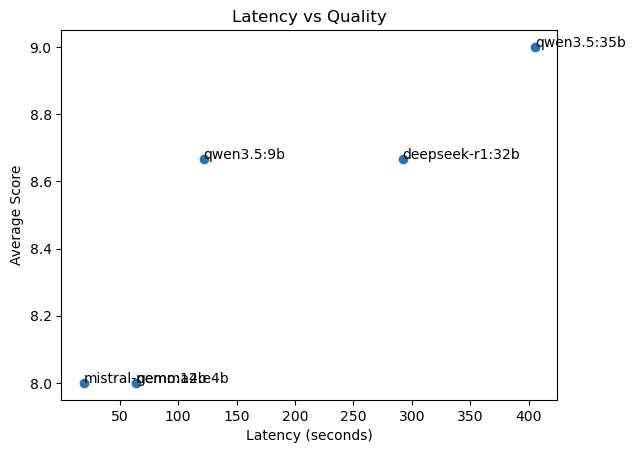

In [2]:
plt.figure()
plt.scatter(df["latency"], df["avg_score"])

for i, model in enumerate(df["model_name"]):
    plt.text(df["latency"][i], df["avg_score"][i], model)

plt.xlabel("Latency (seconds)")
plt.ylabel("Average Score")
plt.title("Latency vs Quality")
plt.show()

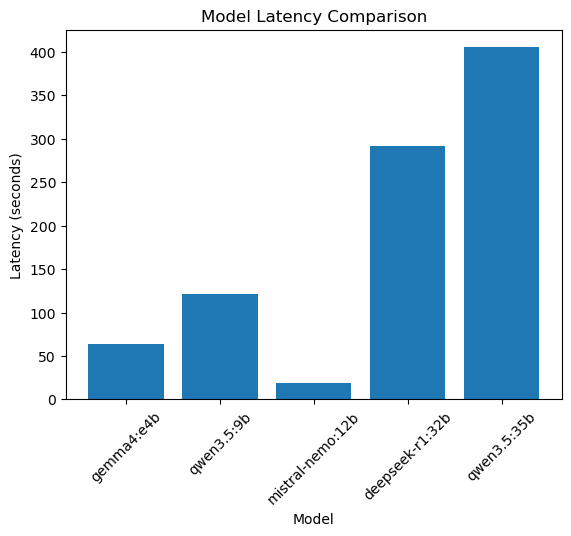

In [3]:
plt.figure()
plt.bar(df["model_name"], df["latency"])
plt.xticks(rotation=45)
plt.xlabel("Model")
plt.ylabel("Latency (seconds)")
plt.title("Model Latency Comparison")
plt.show()

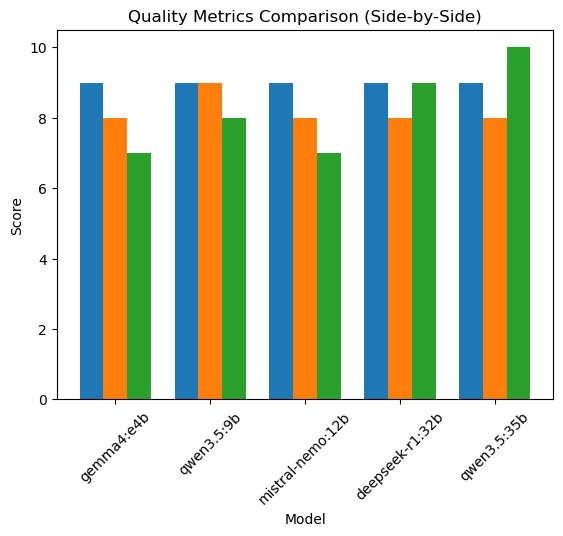

In [4]:
x = np.arange(len(df))
width = 0.25

plt.figure()

plt.bar(x - width, df["faithfulness"], width=width)
plt.bar(x, df["relevance"], width=width)
plt.bar(x + width, df["completeness"], width=width)

plt.xticks(x, df["model_name"], rotation=45)
plt.xlabel("Model")
plt.ylabel("Score")
plt.title("Quality Metrics Comparison (Side-by-Side)")

plt.show()

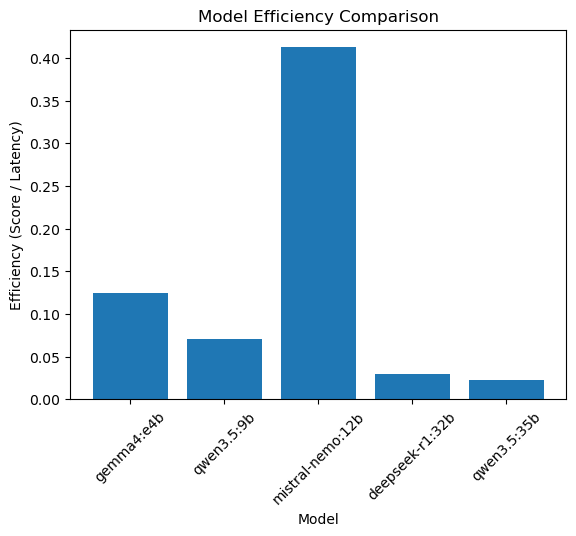

In [5]:
plt.figure()
plt.bar(df["model_name"], df["efficiency"])
plt.xticks(rotation=45)
plt.xlabel("Model")
plt.ylabel("Efficiency (Score / Latency)")
plt.title("Model Efficiency Comparison")
plt.show()

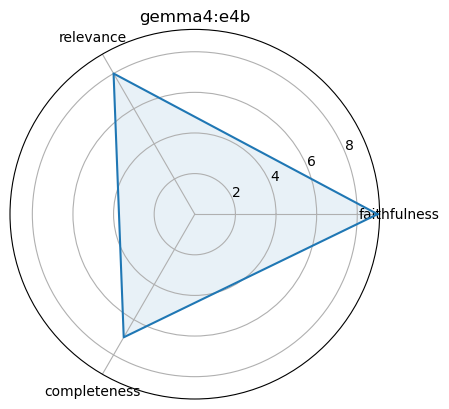

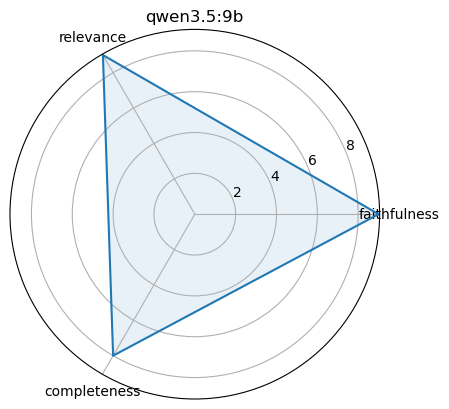

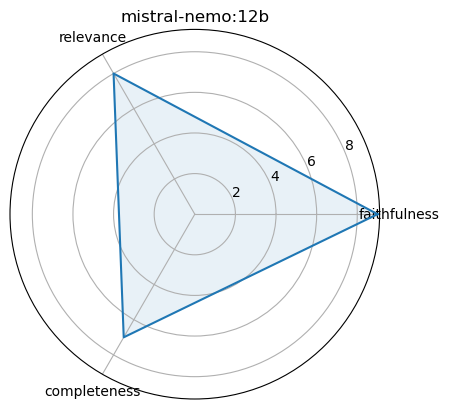

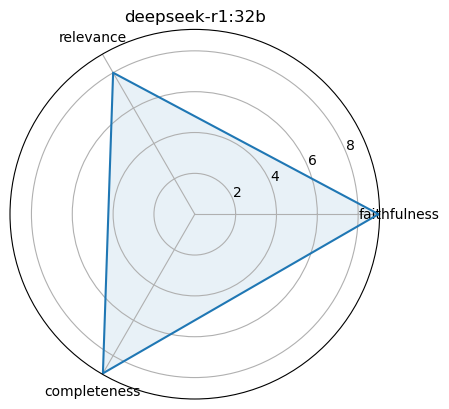

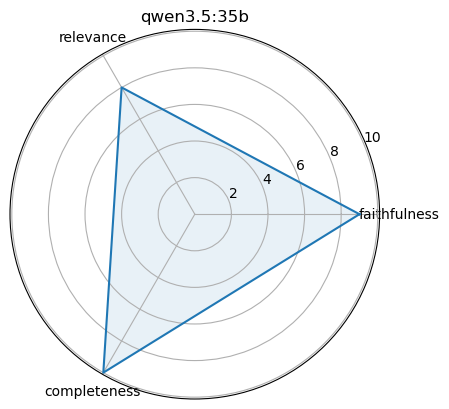

In [6]:
categories = ["faithfulness", "relevance", "completeness"]
num_vars = len(categories)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

for i in range(len(df)):
    values = df.loc[i, categories].tolist()
    values += values[:1]

    plt.figure()
    ax = plt.subplot(111, polar=True)
    ax.plot(angles, values)
    ax.fill(angles, values, alpha=0.1)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories)

    plt.title(df.loc[i, "model_name"])
    plt.show()